In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"adithya2023","key":"b63e4fec55d114dcd7268f59d960e231"}'}

In [ ]:
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.config/kaggle/kaggle.json')
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print("✅ Kaggle credentials set")

✅ Kaggle credentials set


In [ ]:
!kaggle competitions download -c aptos2019-blindness-detection -p /content/

100% 9.51G/9.51G [01:04<00:00, 159MB/s]



In [ ]:
!unzip -q /content/aptos2019-blindness-detection.zip -d /content/aptos2019-blindness-detection
print("✅ Unzip complete")

✅ Unzip complete


In [ ]:
import os
print("Train images :", len(os.listdir('/content/aptos2019-blindness-detection/train_images')))
print("Test  images :", len(os.listdir('/content/aptos2019-blindness-detection/test_images')))

Train images : 3662
Test  images : 1928


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
from functools import partial
print("✅ All imports done")

✅ All imports done


In [ ]:
IMG_SIZE  = 224
BASE_PATH = '/content/aptos2019-blindness-detection'

TRAIN_CSV = os.path.join(BASE_PATH, 'train.csv')
TEST_CSV  = os.path.join(BASE_PATH, 'test.csv')

INPUT_DIRS = {
    'train': os.path.join(BASE_PATH, 'train_images'),
    'test' : os.path.join(BASE_PATH, 'test_images'),
}

# Save preprocessed images to Drive so they persist
OUTPUT_BASE_DIR = '/content/drive/MyDrive/preprocessed_data/'
os.makedirs(OUTPUT_BASE_DIR, exist_ok=True)

# Sanity check
print("TRAIN_CSV exists    :", os.path.exists(TRAIN_CSV))
print("TEST_CSV  exists    :", os.path.exists(TEST_CSV))
print("train_images exists :", os.path.exists(INPUT_DIRS['train']))
print("test_images  exists :", os.path.exists(INPUT_DIRS['test']))

TRAIN_CSV exists    : True
TEST_CSV  exists    : True
train_images exists : True
test_images  exists : True


In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
train_df['path'] = train_df['id_code'].apply(
    lambda x: os.path.join(INPUT_DIRS['train'], f"{x}.png")
)

test_df = pd.read_csv(TEST_CSV)
test_df['path'] = test_df['id_code'].apply(
    lambda x: os.path.join(INPUT_DIRS['test'], f"{x}.png")
)

print(f"Train samples : {len(train_df)}")
print(f"Test  samples : {len(test_df)}")
print(f"\nClass distribution:\n{train_df['diagnosis'].value_counts().sort_index()}")

Train samples : 3662
Test  samples : 1928

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64


In [ ]:
def preprocess_image_optimized(file_path, target_size=IMG_SIZE):
    # 1. Load & convert
    img = cv2.imread(file_path)
    if img is None:
        print(f"[WARNING] Could not read: {file_path}")
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Background masking
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        (x, y), r = cv2.minEnclosingCircle(largest_contour)
        center = (int(x), int(y))
        radius = int(r * 0.95)
        mask = np.zeros_like(gray)
        cv2.circle(mask, center, radius, 255, -1)
        img = cv2.bitwise_and(img, img, mask=mask)
    else:
        print(f"[INFO] No contour found, skipping mask: {file_path}")

    # 3. Green channel
    green_channel = img[:, :, 1]

    # 4. Median blur (denoise before CLAHE)
    denoised_green = cv2.medianBlur(green_channel, 5)

    # 5. CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_green = clahe.apply(denoised_green)

    # 6. Stack to 3-channel & resize
    final_img = np.stack([enhanced_green] * 3, axis=-1)
    final_img = cv2.resize(final_img, (target_size, target_size))

    return final_img

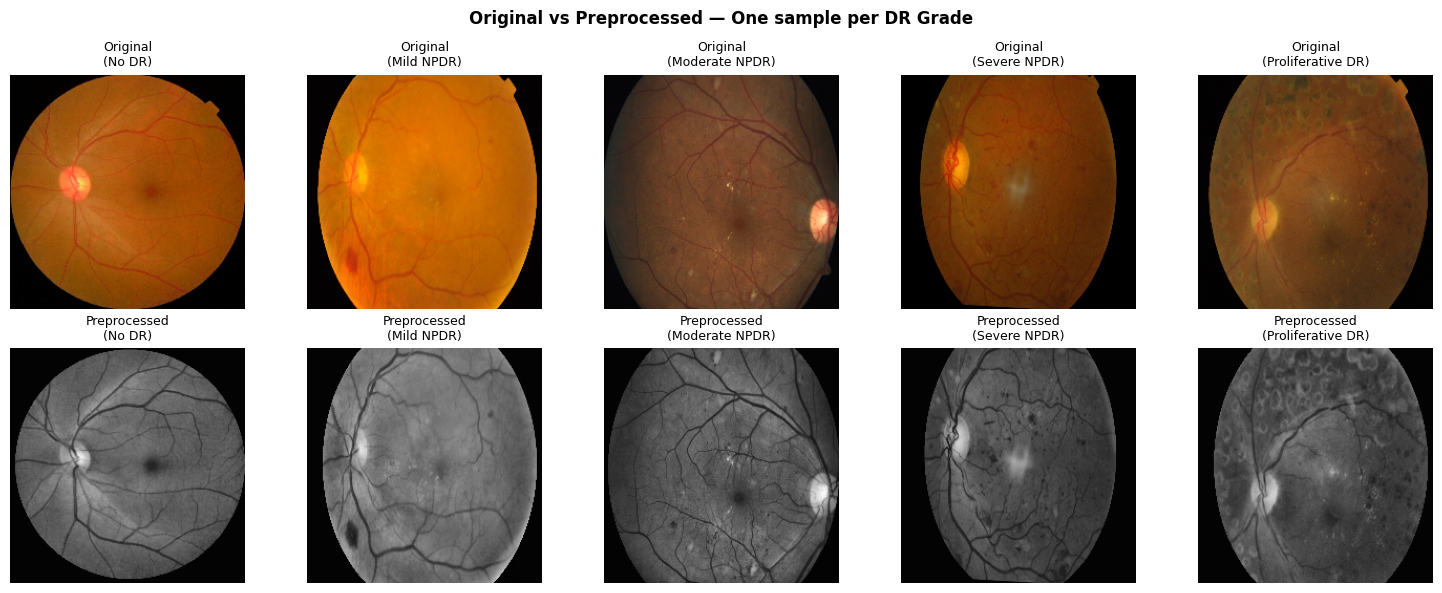

In [ ]:
def visualize_samples(df, n_classes=5):
    classes = ["No DR", "Mild NPDR", "Moderate NPDR", "Severe NPDR", "Proliferative DR"]
    fig, axes = plt.subplots(2, n_classes, figsize=(15, 6))

    for i in range(n_classes):
        subset = df[df['diagnosis'] == i]
        if subset.empty:
            print(f"[WARNING] No samples for class {i}")
            continue

        file_path = subset.sample(1)['path'].values[0]

        if not os.path.exists(file_path):
            print(f"[WARNING] File not found: {file_path}")
            continue

        original  = cv2.cvtColor(cv2.imread(file_path), cv2.COLOR_BGR2RGB)
        original  = cv2.resize(original, (IMG_SIZE, IMG_SIZE))
        processed = preprocess_image_optimized(file_path)

        axes[0, i].imshow(original)
        axes[0, i].set_title(f"Original\n({classes[i]})", fontsize=9)
        axes[0, i].axis('off')

        if processed is not None:
            axes[1, i].imshow(processed)
            axes[1, i].set_title(f"Preprocessed\n({classes[i]})", fontsize=9)
        axes[1, i].axis('off')

    plt.suptitle("Original vs Preprocessed — One sample per DR Grade", fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_samples(train_df)

In [ ]:
def process_and_save_image(file_path, output_dir):
    processed = preprocess_image_optimized(file_path)
    if processed is None:
        return False
    save_path = os.path.join(output_dir, os.path.basename(file_path))
    cv2.imwrite(save_path, cv2.cvtColor(processed, cv2.COLOR_RGB2BGR))
    return True

In [ ]:
def generate_all_datasets(input_dirs, output_base_dir):
    for subset_name, input_dir in input_dirs.items():
        output_dir = os.path.join(output_base_dir, subset_name)
        os.makedirs(output_dir, exist_ok=True)

        print(f"\n--- Processing subset: {subset_name} ---")

        all_files = [
            os.path.join(input_dir, f)
            for f in os.listdir(input_dir)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]

        if not all_files:
            print(f"[SKIP] No images found in: {input_dir}")
            continue

        worker = partial(process_and_save_image, output_dir=output_dir)

        with ThreadPoolExecutor() as executor:
            results = list(tqdm(
                executor.map(worker, all_files),
                desc=f"Processing {subset_name}",
                total=len(all_files)
            ))

        success = sum(results)
        failed  = len(results) - success
        print(f"✅ {subset_name}: {success} saved, {failed} failed → {output_dir}")

In [ ]:
generate_all_datasets(INPUT_DIRS, OUTPUT_BASE_DIR)


--- Processing subset: train ---


Processing train: 100%|██████████| 3662/3662 [28:47<00:00,  2.12it/s]


✅ train: 3662 saved, 0 failed → /content/drive/MyDrive/preprocessed_data/train

--- Processing subset: test ---


Processing test: 100%|██████████| 1928/1928 [14:37<00:00,  2.20it/s]

✅ test: 1928 saved, 0 failed → /content/drive/MyDrive/preprocessed_data/test
